<a href="https://colab.research.google.com/github/Lufsenna/3-fase---2-Telecom-X-An-lise-de-Evas-o-de-Clientes-Churn---Parte-1/blob/main/C%C3%B3pia_de_Conhe%C3%A7a_o_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Telecom X – Análise de Evasão de Clientes (Churn)**

# **1 . Importação das Bibliotecas**

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

**1.1 - Extracão dos dados**

In [2]:
url = ('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json')

In [3]:
resp = requests.get(url)
resp.raise_for_status()
dados = resp.json()

In [4]:
df = pd.json_normalize(dados, sep='_')
df.head(5)
print("Dados carregados com sucesso!")
df.head()

Dados carregados com sucesso!


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


**2.1 - Salvar o arquivo em CSV**

In [5]:
df.to_csv("dados_normalizados.csv", index=False)

# **2. Explorando a Estrutura do Dataset**

2.1 - Visualizar primeiras linhas

In [6]:
df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


2.2 - Estrutura das colunas

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

2.3 - Tipos de dados

In [8]:
df.dtypes

,0
customerID,object
Churn,object
customer_gender,object
customer_SeniorCitizen,int64
customer_Partner,object
customer_Dependents,object
customer_tenure,int64
phone_PhoneService,object
phone_MultipleLines,object
internet_InternetService,object


2.4 - Estatísticas gerais

In [9]:
df.describe()

,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


2.5 - Listar colunas

In [10]:
df.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total'],
      dtype='object')

# **3. Verificando Inconsistências e Tratamentos dos Dados**

3.1 - Valores ausentes

In [11]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


3.2 - Registros duplicados

In [12]:
df.duplicated().sum()

np.int64(0)

3.3 - Categorias da variável churn

In [13]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


3.4 - Categorias de contrato

In [14]:
df['account_Contract'].value_counts()

,count
account_Contract,
Month-to-month,4005
Two year,1743
One year,1519


3.5 - Formas de pagamento

In [15]:
df['account_PaymentMethod'].value_counts()

,count
account_PaymentMethod,
Electronic check,2445
Mailed check,1665
Bank transfer (automatic),1589
Credit card (automatic),1568


# **4. Tratamento das Inconsistências**

4.1 - Remover duplicados caso existam

In [16]:
df = df.drop_duplicates()

4.2 - Garantir que valores numéricos estejam corretos:

In [17]:
df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce')

4.3 - Substituir valores ausentes:

In [18]:
df = df.fillna(0)

4.4 - Remover os registros vazios e espaços na coluna Churn

In [19]:
df = df[df['Churn'].astype(str).str.strip() != ''].copy()

# **5. Criando a Coluna Contas Diarias**

5.1 - Convertendo as colunas para tipo numérico

In [20]:
df['account_Charges_Monthly'] = pd.to_numeric(df['account_Charges_Monthly'], errors='coerce')
df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce')

5.2 - Construir e Mapear Yes/No - 1/0 em colunas numéricas:

In [21]:
cols_yn = [
    'Churn','customer_Partner','customer_Dependents','phone_PhoneService','phone_MultipleLines',
    'internet_OnlineSecurity','internet_OnlineBackup','internet_DeviceProtection',
    'internet_TechSupport','internet_StreamingTV','internet_StreamingMovies','account_PaperlessBilling'
]

df[cols_yn] = df[cols_yn].replace({
    'Yes': 1,
    'No': 0,
    'No internet service': 0,
    'No phone service': 0
})

/tmp/ipykernel_226/1860299715.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols_yn] = df[cols_yn].replace({


5.3 - Inserindo uma nova coluna para saber os valores das cobranças diárias

In [22]:
df['Cobrancas_Diarias'] = df['account_Charges_Monthly'] / 30

print('Dimensão após limpeza:', df.shape)
print('Amostra de dados:')
display(df.head())
print('Tipos e nulos:')

Dimensão após limpeza: (7043, 22)
Amostra de dados:


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,Cobrancas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


Tipos e nulos:


**5.4 - Verificar se há aluguma string escondida**

In [23]:
df[cols_yn].apply(lambda x: x.unique())

,Churn,customer_Partner,customer_Dependents,phone_PhoneService,phone_MultipleLines,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_PaperlessBilling
0,0,1,1,1,0,0,1,0,1,1,0,1
1,1,0,0,0,1,1,0,1,0,0,1,0


**5.5 - Dados**

In [24]:
print('Mostre os Tipos de dados e valores nulos:')
df.info()
print('\nSe houver Quantidade de valores nulos por coluna:')
print(df.isnull().sum())

Mostre os Tipos de dados e valores nulos:
<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   int64  
 2   customer_gender            7043 non-null   object 
 3   customer_SeniorCitizen     7043 non-null   int64  
 4   customer_Partner           7043 non-null   int64  
 5   customer_Dependents        7043 non-null   int64  
 6   customer_tenure            7043 non-null   int64  
 7   phone_PhoneService         7043 non-null   int64  
 8   phone_MultipleLines        7043 non-null   int64  
 9   internet_InternetService   7043 non-null   object 
 10  internet_OnlineSecurity    7043 non-null   int64  
 11  internet_OnlineBackup      7043 non-null   int64  
 12  internet_DeviceProtection  7043 non-null   int64  
 13  internet_Te

**5.6 - Fazer a substituições dos valores nulos (NaN) pela média da coluna**

In [25]:
df['account_Charges_Total'] = df['account_Charges_Total'].fillna(
    df['account_Charges_Total'].mean()
)
print(df.isnull().sum())

customerID                   0
Churn                        0
customer_gender              0
customer_SeniorCitizen       0
customer_Partner             0
customer_Dependents          0
customer_tenure              0
phone_PhoneService           0
phone_MultipleLines          0
internet_InternetService     0
internet_OnlineSecurity      0
internet_OnlineBackup        0
internet_DeviceProtection    0
internet_TechSupport         0
internet_StreamingTV         0
internet_StreamingMovies     0
account_Contract             0
account_PaperlessBilling     0
account_PaymentMethod        0
account_Charges_Monthly      0
account_Charges_Total        0
Cobrancas_Diarias            0
dtype: int64


# **6. Padronização e Transformação de Dados (Opcional)**

**6.1 - Transformar Churn em binário**

In [26]:
df['Churn_binario'] = df['Churn'].map({'No':0,'Yes':1})

**6.2 - Transformar gênero em binário**

In [27]:
df['Genero_binario'] = df['customer_gender'].map({'Female':0,'Male':1})

# **7. Carga e Análise (L - Load & Analysis)**

**7.1 -Distribuição da Evasão - Média das variáveis numéricas**

In [28]:
df[['customer_tenure','account_Charges_Monthly','account_Charges_Total','Cobrancas_Diarias']].mean()

,0
customer_tenure,32.371149
account_Charges_Monthly,64.761692
account_Charges_Total,2279.734304
Cobrancas_Diarias,2.158723


7.2 - **Mediana**

In [29]:
df[['customer_tenure','account_Charges_Monthly','account_Charges_Total','Cobrancas_Diarias']].median()

,0
customer_tenure,29.000
account_Charges_Monthly,70.350
account_Charges_Total,1394.550
Cobrancas_Diarias,2.345


**7.3 - Desvio padrão**

In [30]:
df[['customer_tenure','account_Charges_Monthly','account_Charges_Total','Cobrancas_Diarias']].std()

,0
customer_tenure,24.559481
account_Charges_Monthly,30.090047
account_Charges_Total,2266.794470
Cobrancas_Diarias,1.003002


# **8. Contagem de Evasão (Churn)**

**8.1 - Contagem de Evasão "Proporção de Churn em (%)" (Churn)**

In [31]:
print('Proporção de Churn (%)')
df['Churn'].value_counts(normalize=True).mul(100).reset_index(name='Proporção')

Proporção de Churn (%)


,Churn,Proporção
0,0,73.463013
1,1,26.536987


**8.2 - Dados do Churn,	Valor Médio da cobrança mensal, entre clientes que permanecem e os que cancelam**

In [32]:
df.groupby('Churn')['account_Charges_Monthly'].mean().reset_index(name='Valor Médio')

,Churn,Valor Médio
0,0,61.265124
1,1,74.441332


**8.3 - Média do total dos encargos na conta**

In [33]:
df.groupby('Churn')['account_Charges_Total'].mean().reset_index(name='Média dos encargos')

,Churn,Média dos encargos
0,0,2549.911442
1,1,1531.796094


**8.4 - Valores da taxa média de churn (%) por tipo de contrato**

In [56]:
print('Valores da taxa média de churn (%) por tipo de contrato')
(
    df.groupby('account_Contract')['Churn']
      .mean()
      .mul(100)
      .reset_index(name='Média contrato')
      .sort_values(by='Média contrato', ascending=False)
)

Valores da taxa média de churn (%) por tipo de contrato


,account_Contract,Média contrato
0,Month-to-month,42.709677
1,One year,11.269518
2,Two year,2.831858


**8.5 - Dados relevantes**

In [35]:
servicos = [
    'internet_OnlineSecurity',
    'internet_OnlineBackup',
    'internet_DeviceProtection',
    'internet_TechSupport'
]
df.groupby("Churn")[servicos].mean().mul(100).reset_index()

,Churn,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport
0,0,33.320448,36.838036,36.277542,33.513722
1,1,15.783842,27.982879,29.159979,16.586410


**8.6 - Gráfico 1 - Proporção de Churn em uma Visão Geral**

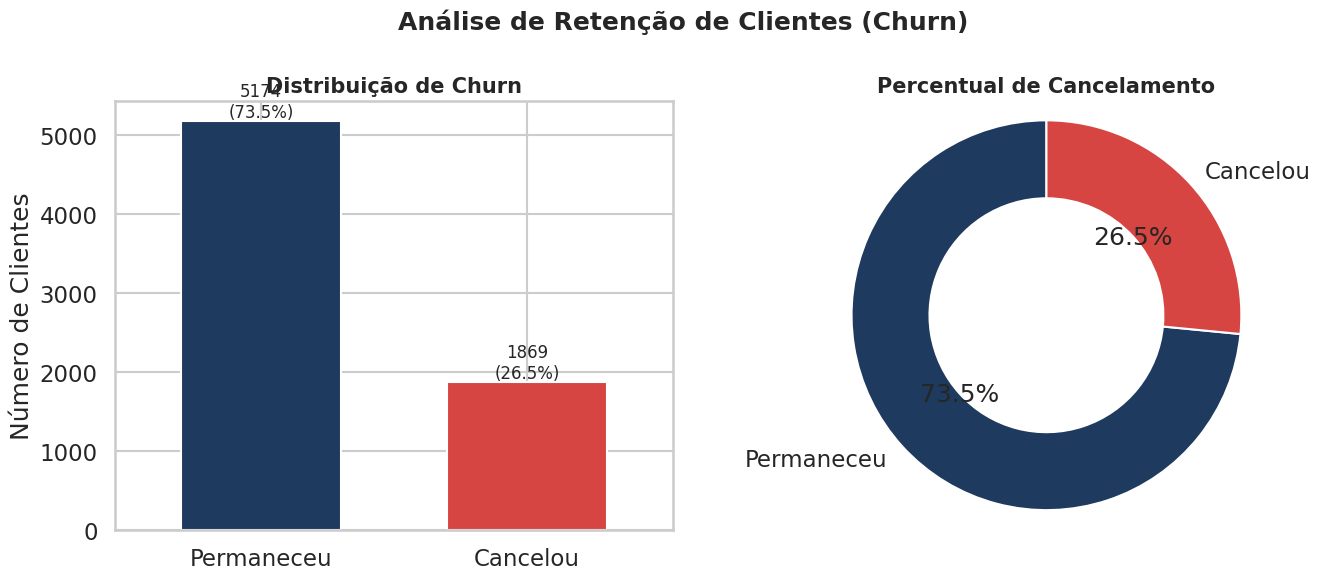

In [36]:
sns.set_theme(style="whitegrid", context="talk")

churn_cnt = df['Churn'].value_counts().sort_index()
churn_pct = df['Churn'].value_counts(normalize=True).sort_index() * 100

cores = ['#1F3A5F', '#D64541']
fig, axes = plt.subplots(1, 2, figsize=(14,6))

ax = churn_cnt.plot(
    kind='bar',
    ax=axes[0],
    color=cores,
    width=0.6
)

for i, p in enumerate(ax.patches):
    ax.annotate(
        f'{p.get_height():.0f}\n({churn_pct.iloc[i]:.1f}%)',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12
    )

axes[0].set_title('Distribuição de Churn', fontsize=15, weight='bold')
axes[0].set_ylabel('Número de Clientes')
axes[0].set_xlabel('')
axes[0].set_xticklabels(['Permaneceu', 'Cancelou'], rotation=0)

axes[1].pie(
    churn_pct,
    labels=['Permaneceu', 'Cancelou'],
    autopct='%1.1f%%',
    startangle=90,
    colors=cores,
    wedgeprops=dict(width=0.40)
)

axes[1].set_title('Percentual de Cancelamento', fontsize=15, weight='bold')
axes[1].axis('equal')

plt.suptitle(
    'Análise de Retenção de Clientes (Churn)',
    fontsize=18,
    weight='bold'
)

plt.tight_layout()
plt.show()

**8.8 - Dados dos clientes**

In [37]:
churn_total = df.shape[0]
churn_cancelados = df['Churn'].sum()
churn_ativos = churn_total - churn_cancelados
churn_pct_cancelados = (churn_cancelados / churn_total) * 100

print(f"Total de clientes que foram analisados: {churn_total}")
print(f"Clientes que cancelaram (Churn): {churn_cancelados}")
print(f"Clientes ativos: {churn_ativos}")
print(f"Percentual de clientes que cancelaram (Churn): {churn_pct_cancelados:.2f}%")
print(f"Insight: Observa-se que aproximadamente 26.5% da base realizou Churn, indicando que a evasão representa um problema relevante e prioritário para a Telecom X.")

Total de clientes que foram analisados: 7043
Clientes que cancelaram (Churn): 1869
Clientes ativos: 5174
Percentual de clientes que cancelaram (Churn): 26.54%
Insight: Observa-se que aproximadamente 26.5% da base realizou Churn, indicando que a evasão representa um problema relevante e prioritário para a Telecom X.


**8.8 - Gráfico 2 - Churn por Tipo de Contrato**

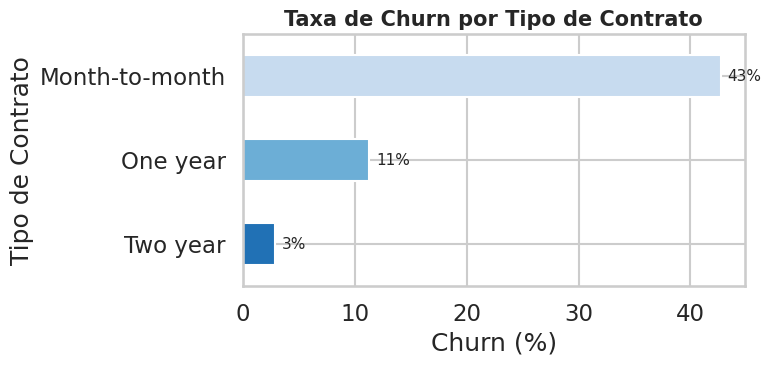

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(8,4))

# Calculate churn_contrato
churn_contrato = (
    df.groupby('account_Contract')['Churn']
      .mean()
      .mul(100)
)

# Paleta elegante em tons de azul
cores = sns.color_palette("Blues_r", len(churn_contrato))

ax = churn_contrato.sort_values().plot(
    kind='barh',
    color=cores
)

plt.title('Taxa de Churn por Tipo de Contrato', fontsize=15, weight='bold')
plt.xlabel('Churn (%)')
plt.ylabel('Tipo de Contrato')

# Valores nas barras
for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.0f}%',
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left',
        va='center',
        fontsize=11,
        xytext=(5,0),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

**8.9 - Dados dos clientes**

In [47]:
churn_contrato = (
    df.groupby('account_Contract')['Churn']
      .mean()
      .mul(100)
)

# Identificar contratos
contrato_maior_churn = churn_contrato.idxmax()
contrato_menor_churn = churn_contrato.idxmin()

# Arredondar valores
valor_maior_churn = round(churn_contrato.max(), 2)
valor_menor_churn = round(churn_contrato.min(), 2)

print(f"Contrato com maior taxa de churn: {contrato_maior_churn}")
print(f"Taxa de churn mais elevada: {valor_maior_churn:.2f}%")

print(f"Contrato com menor taxa de churn: {contrato_menor_churn}")
print(f"Taxa de churn mais baixa: {valor_menor_churn:.2f}%")

Contrato com maior taxa de churn: Month-to-month
Taxa de churn mais elevada: 42.71%
Contrato com menor taxa de churn: Two year
Taxa de churn mais baixa: 2.83%


# **9. Evasão por Variáveis Categóricas**

In [55]:
pd.crosstab(df['account_Contract'], df['Churn'])

Churn,0,1
account_Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [54]:
pd.crosstab(df['account_PaymentMethod'], df['Churn'])

Churn,0,1
account_PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


**9.1 - Gráfico 3 - Tempo de Contrato vs Churn**

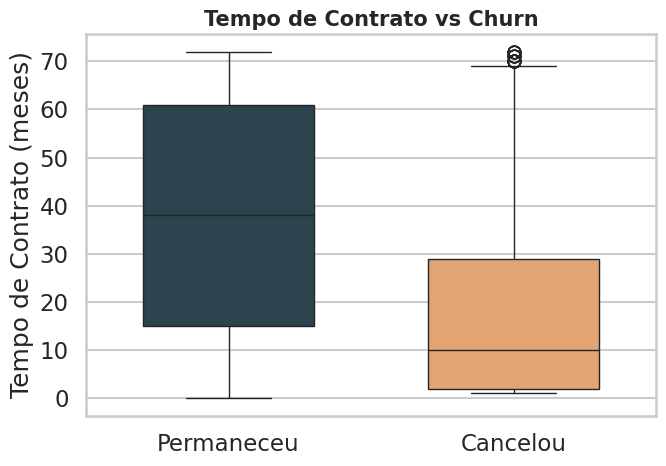

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

cores = ['#264653', '#F4A261']

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Churn',
    y='customer_tenure',
    hue='Churn', # Adicionado para resolver o FutureWarning
    palette=cores,
    legend=False, # Adicionado para resolver o FutureWarning
    width=0.6
)

plt.title('Tempo de Contrato vs Churn', fontsize=15, weight='bold')
plt.xlabel('')
plt.ylabel('Tempo de Contrato (meses)')

plt.xticks([0,1], ['Permaneceu', 'Cancelou'])

plt.tight_layout()
plt.show()

**9.2 - Gráfico 4 - Churn vs Serviços de Suporte**

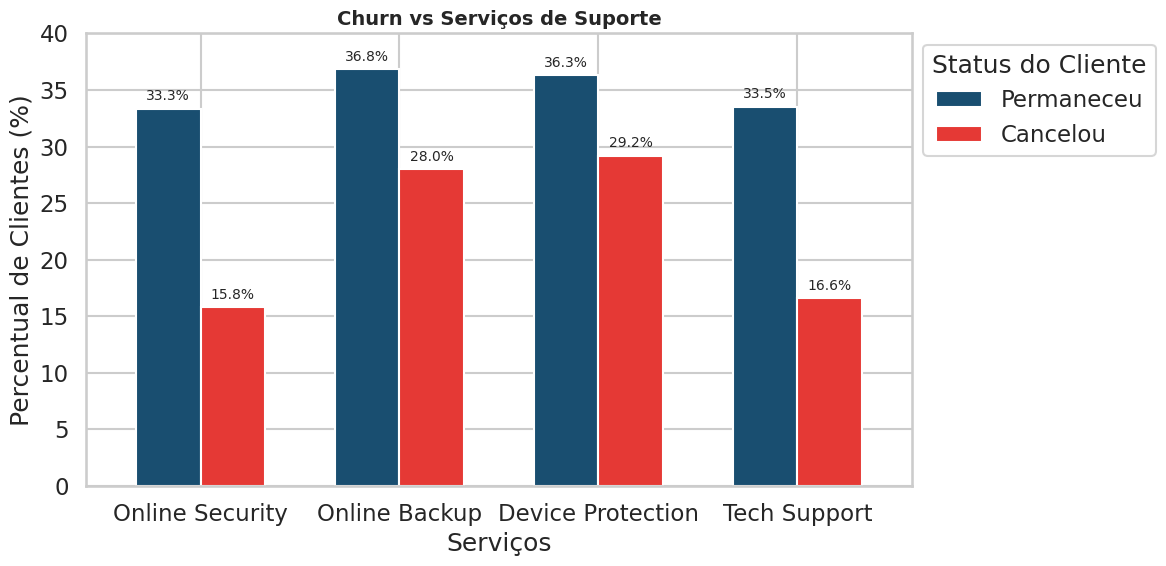

In [65]:
servicos = [
    'internet_OnlineSecurity',
    'internet_OnlineBackup',
    'internet_DeviceProtection',
    'internet_TechSupport'
]
churn_servicos = df.groupby('Churn')[servicos].mean().mul(100).T
churn_servicos.index = [
    'Online Security',
    'Online Backup',
    'Device Protection',
    'Tech Support'
]

ax = churn_servicos.plot(
    kind='bar',
    figsize=(12,6),
    color=['#194E70', '#E53935'],
    width=0.65
)
plt.title('Churn vs Serviços de Suporte', fontsize=14, weight='bold')
plt.ylabel('Percentual de Clientes (%)')
plt.xlabel('Serviços')
plt.xticks(rotation=0)

plt.legend(
    ['Permaneceu', 'Cancelou'],
    title='Status do Cliente',
    loc='upper left',
    bbox_to_anchor=(1,1)
)
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(
        f'{altura:.1f}%',
        (p.get_x() + p.get_width()/2, altura),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(0,4),
        textcoords='offset points'
    )
plt.ylim(0,40)
plt.tight_layout()
plt.show()

# **10. EXTRA – Análise de Correlação**

In [49]:
corr = df[[
    'customer_tenure',
    'account_Charges_Monthly',
    'account_Charges_Total',
    'Cobrancas_Diarias',
    'Churn_binario'
]].corr(numeric_only=True)

**10.1 - Gráfico 5 - Matriz de Correlação**

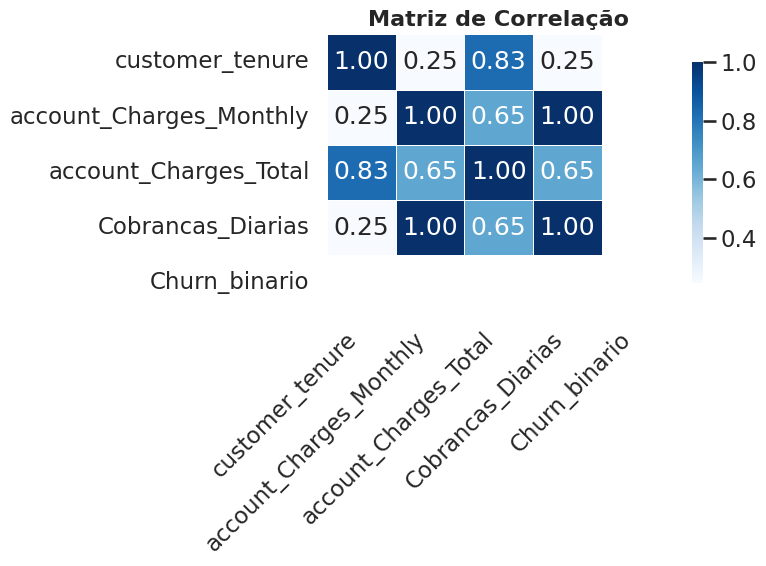

In [67]:
sns.set_theme(style="white", context="talk")

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap=sns.color_palette("Blues", as_cmap=True),
    fmt=".2f",
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlação', fontsize=16, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()